<font size='6'>Perfidio and the search for the lucky passenger</font>

<img src="https://upload.wikimedia.org/wikipedia/commons/9/92/Titanic.jpg" align = "left" width="300">&nbsp;

&nbsp; [Introduction](#intro)

&nbsp;  [1. Importing libraries](#importing_lib)

&nbsp; [2. Importing data](#importing_dat)

&nbsp; [3. Reading data](#reading)

&nbsp; [4. Exploratory data analysis](#eda)

&nbsp; [5. Preprocessing data](#prep_data)

&nbsp; [6. Fitting model](#fit_eva)

# Introduction <a name = 'importing_lib'></a>

----------------------

><span style="color:black">**-Hey, Perfidio! Can I ask you a question?**

><span style="color:black">**-Yes you can. Can I answer?**

><span style="color:black">**-Yes you can. If you were a passenger on the Titanic, what kind of passenger would you like to be?**

><span style="color:black">**-Wow! That's a good question. Let me tell you a story...**

-----------------------

We have a dataset available in kaggle about the Titanic passenger with some information about them. The most interesting thing is that we have information on whether the passengers survived or not. Here we have a brief description of the data we have for each passenger:

* **PassengerId**: The identificator is a diferent number for each passenger  
* **Survived**: Did the passenger survived? 
* **Pclass**: Did the passenger travel in low, medium or high class? 
* **Name**: What is the passenger's name?
* **Sex**: The paseenger 
* **Age**: Was the passenger male or female?
* **SibSp**: Number of siblings / spouses of the passenger
* **Parch**: Number of parents / children of the passenger
* **Ticket**: Ticket number
* **Fare**: Price of the bill
* **Cabin**: Passenger cabin number
* **Embarked**: Port of embarkation

So, I think that we can determine the type of passenger that had more chances of surviving using data scientists techinques. Let's start!

# 1. Importing libraries <a name = 'importing_lib'></a>

First of all, we are going to import the tools 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing

import seaborn as sns #graphics
import matplotlib.pyplot as plt #graphics
import pylab # customize graphics

from sklearn.experimental import enable_iterative_imputer # for imputing variables
from sklearn.impute import IterativeImputer # for imputing variables
from sklearn.impute import KNNImputer # for impute missing values

from sklearn.tree import DecisionTreeClassifier # for decision tree implementation

# 2. Importing data <a name = 'importing_dat'></a>
We take the data...

In [2]:
train_filepath = '../input/titanic/train.csv'
test_filepath = '../input/titanic/test.csv'

In [3]:
train_data = pd.read_csv(train_filepath)
test_data = pd.read_csv(test_filepath)

# 3. Reading data <a name = 'reading'></a>
After import the data, we must to know all as be posible about our dataset:

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
len(test_data)

418

## Number of rows and columns
Knowing the number of observations/rows and variables/columns is essential in our data analysis.

In [7]:
print( 'the dataset contains',train_data.shape[0], 'and', train_data.shape[1], 'columns')

the dataset contains 891 and 12 columns


## Type of each column
A quick way to see what kind of data contains each column.

In [8]:
train_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
for i in  range(0,len(train_data.dtypes.value_counts())):
    print('There are', train_data.dtypes.value_counts()[i], ' variables of',train_data.dtypes.value_counts().index[i], 'type')

There are 5  variables of object type
There are 5  variables of int64 type
There are 2  variables of float64 type


## Number of different values of each variable
to find out how much variety each variable has


In [10]:
train_data.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Let's see Which values are:

In [11]:
col_names = ['Pclass','SibSp','Parch','Embarked']

for col in col_names:
    print(train_data[col].name,train_data[col].unique())

Pclass [3 1 2]
SibSp [1 0 3 4 2 5 8]
Parch [0 1 2 5 3 4 6]
Embarked ['S' 'C' 'Q' nan]


## Number of missing values per column
We must treat the missing values ​​appropriately to obtain the most accurate predictions.

In [12]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We have some missing values for ```Age```, ```Cabin``` and ```Age```. And proportionally?

In [13]:
train_data.isna().sum()/len(train_data)

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

As we can see, more than the 77.10% of the sample has no data about ```Cabin```. Initially we are not going to do a treatment for this variable, but later we are going to **impute the ```Age```**.

## Descriptive statistics for numerical variables
This will give us a lot of information about the data

In [14]:
round(train_data.describe(),2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


# 4. Exploratory data analysis <a name = 'eda'></a>

For a better understanding of the data and to detect correlation we will plot some graphics

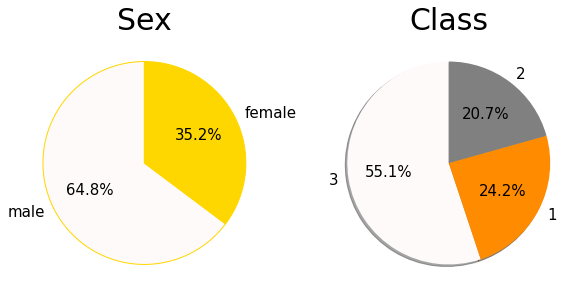

In [15]:
fig1=plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
train_data.Sex.value_counts().plot(kind = 'pie',autopct='%1.1f%%', startangle=90, title = 'Sex', 
                                   fontsize = 15, colors = ['snow', 'gold'], wedgeprops={"edgecolor":"gold"}).title.set_size(30)
pylab.ylabel('')
plt.subplot(1,2,2)
train_data.Pclass.value_counts().plot(kind = 'pie',autopct='%1.1f%%', startangle=90, title = 'Class',
                                    fontsize = 15, colors = ['snow', 'darkorange', 'gray'], shadow = True).title.set_size(30)
pylab.ylabel('')
fig1.show()

There are more women than men, and the most common ticket is third class

Text(0.5, 1.0, 'Age distribution')

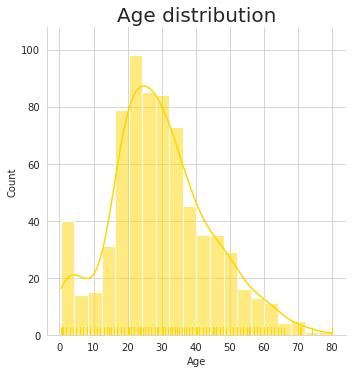

In [16]:
sns.set_style("whitegrid")
sns.displot(data=train_data['Age'], kind = ('hist'), kde = True,rug = True, color = 'gold')
plt.title("Age distribution", size=20)

There is an elevated number of babies (age near to 0) and most have between 20 and 40 years old

Text(0.5, 1.0, 'Proportion survivors by genre ')

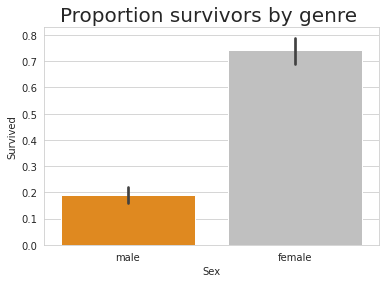

In [17]:
sns.barplot(x="Sex", y="Survived", data=train_data, palette = ('darkorange','silver'))
plt.title("Proportion survivors by genre ", size=20)

Look! It seems that women have much more chances to survive

Text(0.5, 1.0, 'Proportion survivors by number of siblings/spouses')

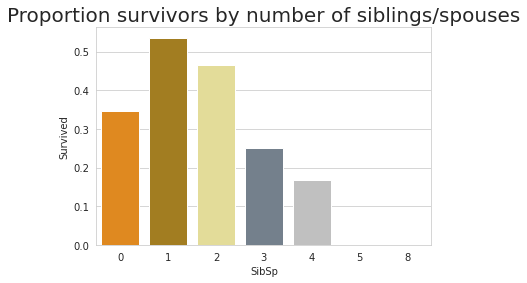

In [18]:
bar_colors = ('darkorange', 'darkgoldenrod', 'khaki','slategray', 'silver', 'royalblue')
sns.barplot(x="SibSp", y="Survived", data=train_data, ci=None, palette = bar_colors)
plt.title("Proportion survivors by number of siblings/spouses", size=20)

And passengers with just one sibling or spouse as companion have more chances too

Text(0.5, 1.0, 'Proportion survivors by number of parents/children')

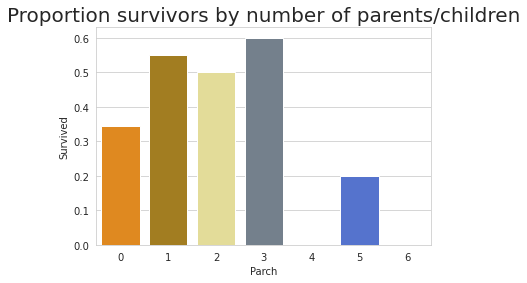

In [19]:
sns.barplot(x="Parch", y="Survived", data=train_data, ci=None, palette = bar_colors)
plt.title("Proportion survivors by number of parents/children", size=20)

In this graph we can see that is not clear if the pasenger who have 3 parents or children on board have more probabilites to survive,these have a high variance

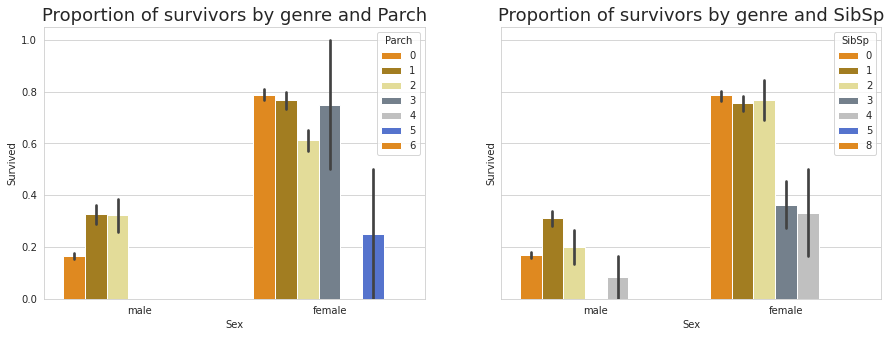

In [20]:
fig2, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.barplot(ax= axes[0], x="Sex", y="Survived", hue="Parch", data=train_data, palette = bar_colors, ci = 50)
axes[0].set_title('Proportion of survivors by genre and Parch', size = 18)
sns.barplot(ax = axes[1], x="Sex", y="Survived", hue="SibSp", data=train_data, palette = bar_colors, ci = 50)
axes[1].set_title('Proportion of survivors by genre and SibSp', size = 18)
fig2.show()


There are a lot of differences between genres

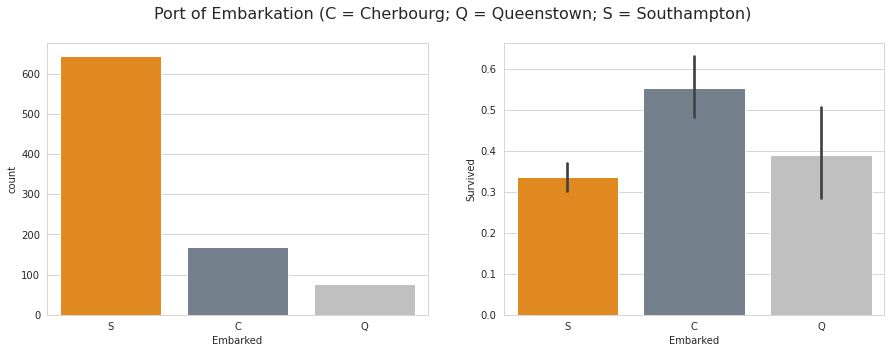

In [21]:
bar_colors1 = ('darkorange','slategray', 'silver')
fig3, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(ax= axes[0], x = train_data['Embarked'],  palette = bar_colors1)
sns.barplot(ax= axes[1], x="Embarked", y="Survived", data=train_data,  palette = bar_colors1)
fig3.suptitle('Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)', fontsize=16)
fig3.show()

## Matrix correlation
Matrix and correlation graph of numerical variables

In [22]:
corr = train_data.iloc[:, 1:11].corr(); corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<AxesSubplot:>

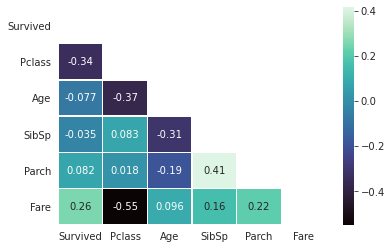

In [23]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, 
               xticklabels=corr.columns.values,
               yticklabels=corr.columns.values,
           linewidths = 0.5, cmap='mako', mask = mask, annot = True)

# 5. Preprocessing data <a name = 'prep_data'></a>

An essential previus step to fit our models is to adapt our data for obtain better predictions

Detect and delete outliers

Change categorical values to binary values 

Classify names by its title (Mr, Mrs, Master...) https://www.kaggle.com/startupsci/titanic-data-science-solutions

https://www.kaggle.com/gunesevitan/titanic-advanced-feature-engineering-tutorial



We start replacing the Sex variables from categorical values to numerical values

In [24]:
train_data['Sex'].replace(['female','male'],[0,1],inplace=True)
train_data['Sex'].dtypes

dtype('int64')

As we saw before, the `Cabin` variable has a lot of missing values, so we delete it

In [25]:
del train_data['Cabin']

The other variable with some missing values is the `Age`, but in this chase we are going to impute these values because the age is a relevant information for predict if the pasenger survived or not

In [26]:

imp = KNNImputer(n_neighbors = 1, weights = 'uniform')
train_data['Age'] = imp.fit_transform(train_data[['Age']])

train_data['Age'].isna().sum()

0

If we remember, there are two missing values in `embarked` variable, so we will drop these two rows

In [27]:
train_data = train_data[pd.notnull(train_data['Embarked'])]
train_data['Embarked'].isna().sum()


0

Now, we should not have any missing value:

In [28]:
train_data.isnull().values.any()

False

We assign a number of each Port of ombarkation in order to the surviving probability

In [29]:
#train_data['Embarked'].replace(['S','C', 'Q'],[3,1,2],inplace=True)
train_data = train_data.join(pd.get_dummies(train_data[['Embarked']]), how = 'left')

# 6. Fitting model <a name = 'fit'></a>

Finally, we apply the same preprocessing to the test data

In [30]:
y = train_data['Survived']
features = ['Pclass', 'Sex', 'SibSp', 'Parch','Age', 'Fare', 'Embarked_C', 'Embarked_Q','Embarked_S']
X = train_data[features]

test_data['Sex'].replace(['female','male'],[0,1],inplace=True)
test_data['Age'] = imp.fit_transform(test_data[['Age']])
#test_data = test_data[pd.notnull(test_data['Embarked'])]
#test_data = test_data[pd.notnull(test_data['Fare'])]
test_data['Fare'] = imp.fit_transform(test_data[['Fare']])
#test_data['Embarked'].replace(['S','C', 'Q'],[3,1,2],inplace=True)
test_data = test_data.join(pd.get_dummies(test_data[['Embarked']]), how = 'left')
X_test = test_data[features]
X_test.isnull().sum()

Pclass        0
Sex           0
SibSp         0
Parch         0
Age           0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [31]:
len(X_test)

418

Fit the model and save predictions

In [32]:
tree_model = DecisionTreeClassifier(max_leaf_nodes = 500, criterion = 'gini')
                                   
tree_model.fit(X, y)
tree_predictions = tree_model.predict(X_test)

In [33]:
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': tree_predictions})
output.to_csv('my_submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


----------------------

><span style="color:black">**-Hey, Perfidio! You have not asnwered my question!**

><span style="color:black">**-Uhhmmm... What was the question?**

><span style="color:black">**-Ohh, dammit... really? I asked you what was the survivor...**

><span style="color:black">**-Ok, boy! I remember it, but may be next time...**

-----------------------